Training SOM for 2000 iterations...
Training complete. Generating animation...


/Users/daniel/Dev/GitHub/Repositories/machine-learning-portfolio/.venv/lib/python3.9/site-packages/matplotlib/animation.py:872: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


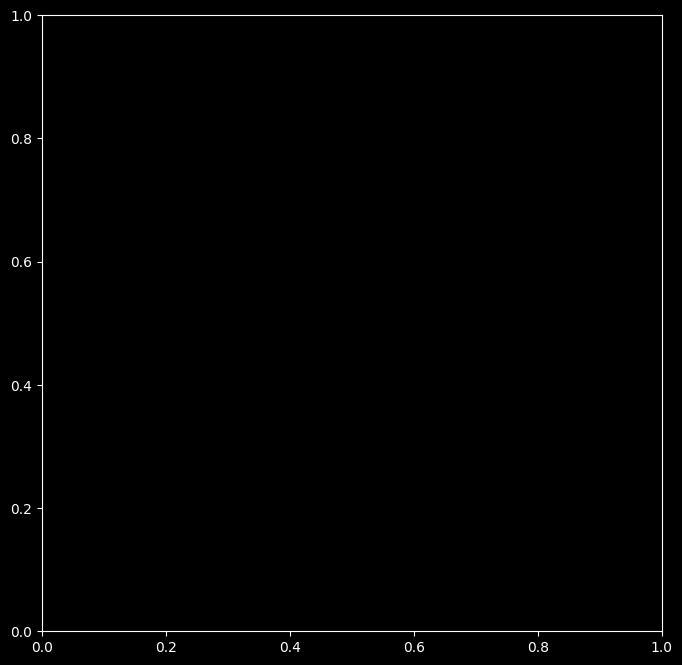

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# --- 1. CONFIGURATION ---
GRID_HEIGHT = 10
GRID_WIDTH = 10
ITERATIONS = 2000      # Total training steps
SNAPSHOTS = 50         # How many frames to show in the animation
LEARNING_RATE = 0.5
RADIUS = 4.0           # Initial neighborhood radius

# --- 2. GENERATE DUMMY DATA (4 CLUSTERS) ---
# We create 4 blobs of data in a 2D space (0 to 1)
def generate_data(n_samples=500):
    # Cluster centers
    centers = [[0.2, 0.2], [0.8, 0.2], [0.2, 0.8], [0.8, 0.8]]
    data = []
    for _ in range(n_samples):
        # Pick a random center
        center = centers[np.random.randint(len(centers))]
        # Add some noise to create a blob
        point = np.array(center) + np.random.normal(scale=0.05, size=2)
        data.append(point)
    return np.array(data)

data = generate_data()

# --- 3. THE SOM CLASS ---
class SimpleSOM:
    def __init__(self, height, width, input_dim):
        self.height = height
        self.width = width
        self.input_dim = input_dim
        
        # Initialize weights randomly in the middle (0.4 to 0.6)
        # This makes the "unfolding" easy to see
        self.weights = np.random.uniform(0.4, 0.6, (height, width, input_dim))
        
        # Pre-compute grid coordinates for easier distance calculations later
        self.grid_coords = np.array([
            [i, j] for i in range(height) for j in range(width)
        ])

    def get_winner(self, input_vec):
        # Flatten weights to finding the winner easier: (N_nodes, input_dim)
        flat_weights = self.weights.reshape(-1, self.input_dim)
        
        # Euclidean distance between input and all weights
        dists = np.linalg.norm(flat_weights - input_vec, axis=1)
        
        # Get index of winner (1D index)
        winner_idx_1d = np.argmin(dists)
        
        # Convert back to 2D grid coordinates (row, col)
        return np.unravel_index(winner_idx_1d, (self.height, self.width))

    def update(self, input_vec, winner_coords, learn_rate, radius):
        winner_y, winner_x = winner_coords
        
        # Iterate over all nodes to update weights based on neighborhood
        for y in range(self.height):
            for x in range(self.width):
                # Calculate "Grid Distance" (Euclidean distance on the grid indices)
                # How far is node(y,x) from winner(wy, wx)?
                dist = np.sqrt((y - winner_y)**2 + (x - winner_x)**2)
                
                # If within radius, update weight
                if dist <= radius:
                    # Influence drops as distance increases (Gaussian-like)
                    influence = np.exp(-(dist**2) / (2 * (radius**2)))
                    
                    # Update Weight: W_new = W_old + (LR * Influence * Delta)
                    self.weights[y, x] += learn_rate * influence * (input_vec - self.weights[y, x])

# --- 4. TRAINING AND ANIMATION SETUP ---

som = SimpleSOM(GRID_HEIGHT, GRID_WIDTH, 2)
fig, ax = plt.subplots(figsize=(8, 8))

# Store history of weights for animation playback
history = []

print(f"Training SOM for {ITERATIONS} iterations...")

# Training Loop
for i in range(ITERATIONS):
    # Decay Learning Rate and Radius over time
    # (Starts high, ends low)
    curr_lr = LEARNING_RATE * (1 - i / ITERATIONS)
    curr_radius = RADIUS * (1 - i / ITERATIONS)
    
    # Pick random data point
    idx = np.random.randint(0, len(data))
    input_vec = data[idx]
    
    # Find Winner
    winner = som.get_winner(input_vec)
    
    # Update Weights
    som.update(input_vec, winner, curr_lr, curr_radius)
    
    # Save snapshot every N steps
    if i % (ITERATIONS // SNAPSHOTS) == 0:
        history.append(som.weights.copy())

# Add final state
history.append(som.weights.copy())
print("Training complete. Generating animation...")

# --- 5. VISUALIZATION FUNCTION ---

def animate(frame_idx):
    ax.clear()
    ax.set_title(f"Iteration: {frame_idx * (ITERATIONS // SNAPSHOTS)}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    # 1. Plot the Input Data (Background Gray)
    ax.scatter(data[:, 0], data[:, 1], color='gray', alpha=0.3, s=10, label="Data")
    
    # Get current weights from history
    current_weights = history[frame_idx]
    
    # 2. Plot the SOM "Grid Lines"
    # Vertical lines (connect (i, j) to (i+1, j))
    for i in range(GRID_HEIGHT):
        ax.plot(current_weights[i, :, 0], current_weights[i, :, 1], 'r-', alpha=0.5)
        
    # Horizontal lines (connect (i, j) to (i, j+1))
    for j in range(GRID_WIDTH):
        ax.plot(current_weights[:, j, 0], current_weights[:, j, 1], 'r-', alpha=0.5)
        
    # 3. Plot the SOM Nodes (Red Dots)
    # Flatten just for scatter plotting
    flat_w = current_weights.reshape(-1, 2)
    ax.scatter(flat_w[:, 0], flat_w[:, 1], color='red', s=30, zorder=10, label="SOM Nodes")
    
    if frame_idx == 0:
        ax.legend(loc='upper right')

# Create Animation
ani = animation.FuncAnimation(fig, animate, frames=len(history), interval=100, repeat=True)

plt.show()